# TinyBench — Evaluation Results Analysis

Load all graded JSON files, tag each entry with its eval mode (raw / tools / semantic),
and visualise performance across models, modes, templates, datasets, and injector categories.

In [76]:
import json, re, warnings
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")

# ── Global style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.35,
    "grid.linestyle": "--",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

GRADE_COLORS = {
    "CORRECT":   "#2ecc71",
    "PARTIAL":   "#f39c12",
    "INCORRECT": "#e74c3c",
}

PROVIDER_COLORS = {
    "Anthropic": "#3b82f6",
    "OpenAI":    "#22c55e",
    "Ollama":    "#f97316",
}

TEMPLATE_CATEGORY = {
    "anomaly_riskier_group_v0":       "surprise_anomaly",
    "anomaly_data_quality_filter_v0": "surprise_anomaly",
    "anomaly_data_quality_filter_v1": "surprise_anomaly",
    "fi_leakage_topk_v0":             "feature_importance",
    "rca_performance_improve_v0":     "root_cause",
    "rca_retrain_point_v0":           "root_cause",
}

# ── Infer mode from filename ──────────────────────────────────────────────
def infer_mode(filename: str) -> str:
    if "_raw_" in filename:
        return "raw"
    if "_semantic_" in filename:
        return "semantic"
    if "_tools_" in filename:
        return "tools"
    return "unknown"

def infer_provider(model: str) -> str:
    if "claude" in model.lower():
        return "Anthropic"
    if "gpt" in model.lower() or "o1" in model.lower() or "o3" in model.lower():
        return "OpenAI"
    return "Ollama"

# ── Load all graded files ─────────────────────────────────────────────────
GRADED_DIR = Path("../data/results/graded")
paths = sorted(GRADED_DIR.glob("*_graded.json"))
print(f"Found {len(paths)} graded files: {[p.name for p in paths]}")

records = []
for path in paths:
    mode = infer_mode(path.name)
    with open(path) as f:
        data = json.load(f)
    for entry in data:
        entry["mode"] = mode
        entry["_source"] = path.name
        records.append(entry)

df = pd.DataFrame(records)
df["provider"] = df["model"].apply(infer_provider)
df["category"] = df["template_id"].map(TEMPLATE_CATEGORY).fillna("unknown")

# Parse dataset size from name (e.g. bike_sharing_100 -> 100)
def _parse_size(name):
    parts = name.rsplit("_", 1)
    if len(parts) == 2 and parts[1].isdigit():
        return int(parts[1])
    return None

df["dataset_size"] = df["dataset"].apply(_parse_size)

# ── Flag context-length errors ────────────────────────────────────────────
def _is_context_error(answer):
    s = str(answer)
    return ("prompt is too long" in s
            or "maximum context length" in s
            or "too many tokens" in s.lower())

df["is_error"] = df["model_answer"].apply(
    lambda a: isinstance(a, str) and str(a).startswith("ERROR")
)
df["is_context_error"] = df["model_answer"].apply(_is_context_error)

print(f"\nTotal records: {len(df)}")
print(f"Models: {sorted(df['model'].unique())}")
print(f"Modes: {df['mode'].value_counts().to_dict()}")
print(f"Grades: {df['grade'].value_counts().to_dict()}")
print(f"Errors (any): {df['is_error'].sum()}")
print(f"Context-length errors: {df['is_context_error'].sum()}")
print(f"Datasets: {sorted(df['dataset'].unique())}")

Found 4 graded files: ['eval_results_api_raw_graded.json', 'eval_results_api_semantic_graded.json', 'eval_results_api_tools_graded.json', 'eval_results_qwen_tools_graded.json']

Total records: 810
Models: ['claude-opus-4-6', 'claude-sonnet-4-5-20250929', 'deepseek-r1:70b', 'gpt-4o', 'gpt-4o-mini', 'qwen2.5:32b', 'qwen2.5:72b']
Modes: {'tools': 346, 'raw': 232, 'semantic': 232}
Grades: {'INCORRECT': 555, 'CORRECT': 217, 'PARTIAL': 38}
Errors (any): 192
Context-length errors: 192
Datasets: ['bike_sharing_100', 'bike_sharing_1000', 'bike_sharing_10000', 'bike_sharing_500', 'california_housing_100', 'california_housing_1000', 'california_housing_10000', 'california_housing_500', 'vgsales_100', 'vgsales_1000', 'vgsales_10000', 'vgsales_500']


---
## 1 — Overall accuracy by model

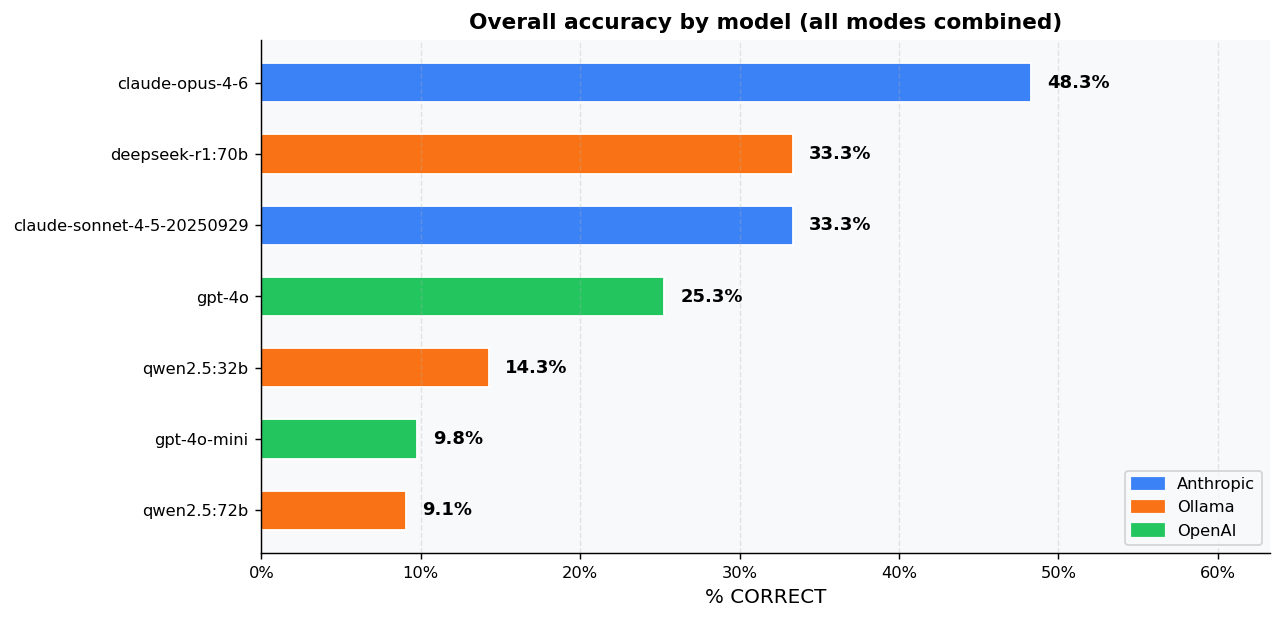

In [77]:
# % CORRECT per model across all modes, sorted descending, colored by provider
acc_by_model = (
    df.groupby("model")["grade"]
    .apply(lambda g: (g == "CORRECT").mean())
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, max(3, len(acc_by_model) * 0.7)))
colors = [PROVIDER_COLORS[infer_provider(m)] for m in acc_by_model.index]
bars = ax.barh(acc_by_model.index, acc_by_model.values, color=colors, height=0.55, edgecolor="white")

for bar, v in zip(bars, acc_by_model.values):
    ax.text(v + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{v:.1%}", va="center", fontsize=10, fontweight="bold")

ax.set_xlim(0, min(acc_by_model.max() + 0.15, 1.0))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel("% CORRECT")
ax.set_title("Overall accuracy by model (all modes combined)")

present = sorted(df["provider"].unique())
legend_patches = [Patch(color=PROVIDER_COLORS[p], label=p) for p in present]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)
ax.grid(axis="y", alpha=0)

plt.tight_layout()
plt.show()

Records after excluding context-length errors: 618 / 810


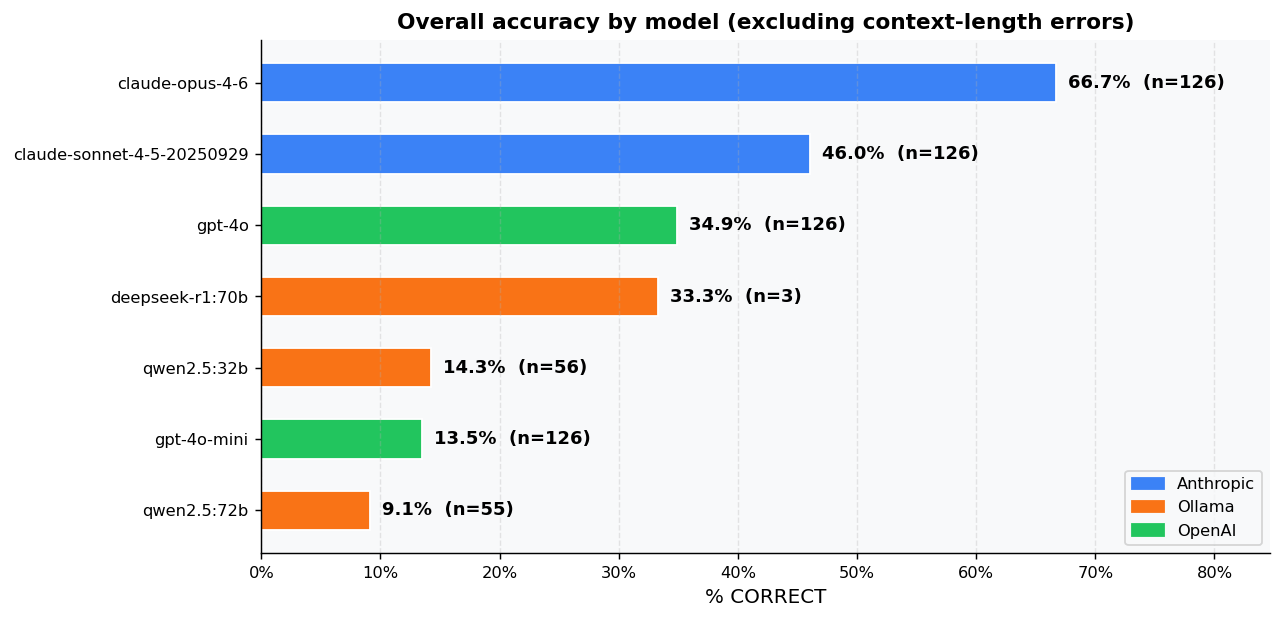

In [78]:
# Same chart but excluding context-length errors
df_ok = df[~df["is_context_error"]]
print(f"Records after excluding context-length errors: {len(df_ok)} / {len(df)}")

acc_excl = (
    df_ok.groupby("model")["grade"]
    .apply(lambda g: (g == "CORRECT").mean())
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, max(3, len(acc_excl) * 0.7)))
colors = [PROVIDER_COLORS[infer_provider(m)] for m in acc_excl.index]
bars = ax.barh(acc_excl.index, acc_excl.values, color=colors, height=0.55, edgecolor="white")

for bar, v, m in zip(bars, acc_excl.values, acc_excl.index):
    n = len(df_ok[df_ok["model"] == m])
    ax.text(v + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{v:.1%}  (n={n})", va="center", fontsize=10, fontweight="bold")

ax.set_xlim(0, min(acc_excl.max() + 0.18, 1.0))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel("% CORRECT")
ax.set_title("Overall accuracy by model (excluding context-length errors)")

present = sorted(df_ok["provider"].unique())
legend_patches = [Patch(color=PROVIDER_COLORS[p], label=p) for p in present]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)
ax.grid(axis="y", alpha=0)

plt.tight_layout()
plt.show()

---
## 2 — Grade distribution by model (stacked bar)

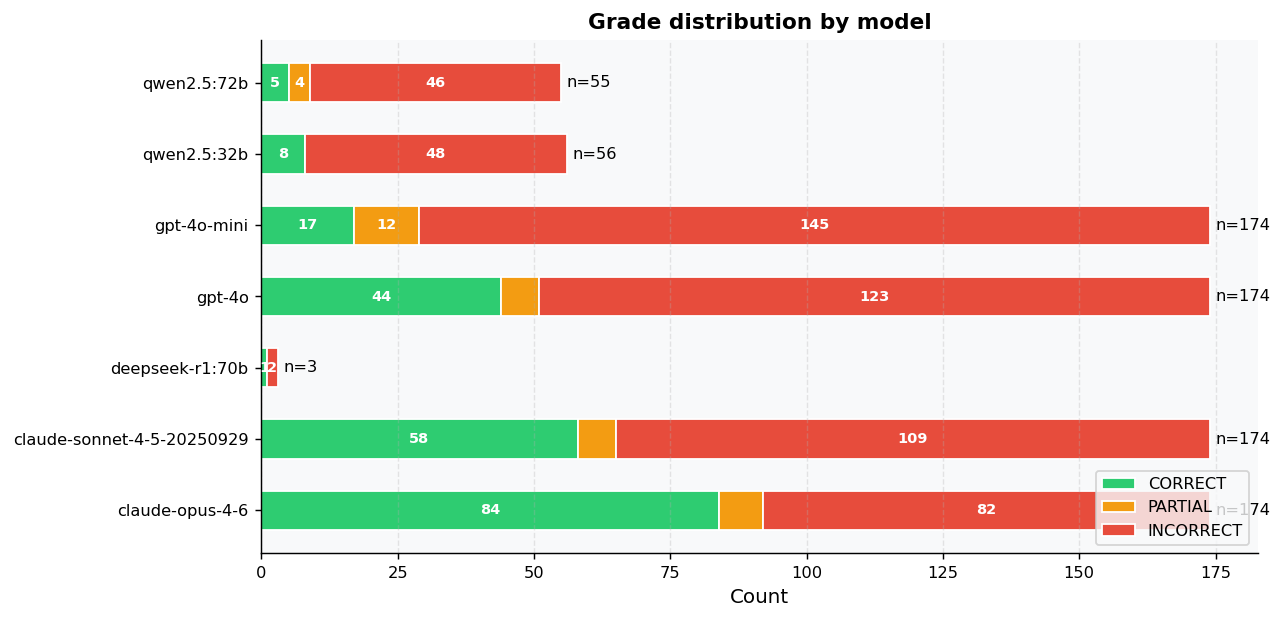

In [79]:
GRADE_ORDER = ["CORRECT", "PARTIAL", "INCORRECT"]
models = sorted(df["model"].unique())

counts = df.groupby(["model", "grade"]).size().unstack(fill_value=0)
# Ensure all grade columns exist
for g in GRADE_ORDER:
    if g not in counts.columns:
        counts[g] = 0
counts = counts[GRADE_ORDER].loc[models]

fig, ax = plt.subplots(figsize=(10, max(3, len(models) * 0.7)))

lefts = np.zeros(len(models))
for grade in GRADE_ORDER:
    vals = counts[grade].values
    ax.barh(models, vals, left=lefts, color=GRADE_COLORS[grade],
            label=grade, height=0.55, edgecolor="white")
    # Label inside bar if large enough
    for i, (v, l) in enumerate(zip(vals, lefts)):
        if v > counts.sum(axis=1).iloc[i] * 0.06:
            ax.text(l + v / 2, i, str(v), ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
    lefts += vals

# Total annotation
for i, m in enumerate(models):
    total = counts.loc[m].sum()
    ax.text(total + 1, i, f"n={total}", va="center", fontsize=9)

ax.set_xlabel("Count")
ax.set_title("Grade distribution by model")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)
ax.grid(axis="y", alpha=0)

plt.tight_layout()
plt.show()

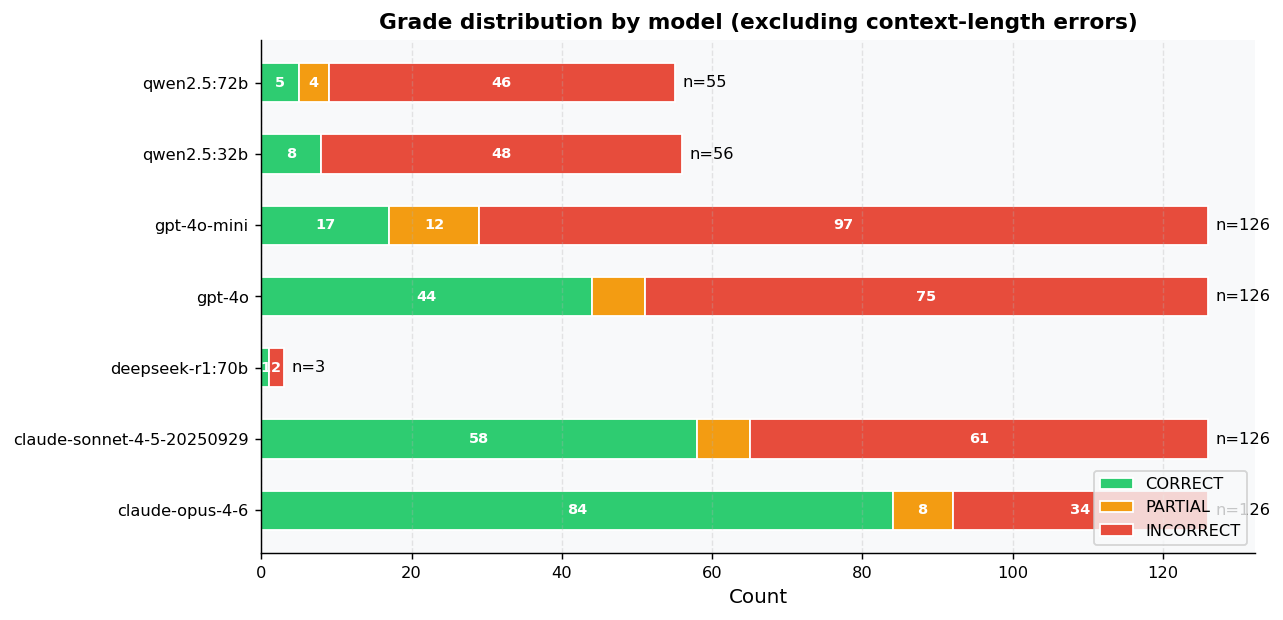

In [80]:
# Same stacked bar but excluding context-length errors
models_ok = sorted(df_ok["model"].unique())

counts_ok = df_ok.groupby(["model", "grade"]).size().unstack(fill_value=0)
for g in GRADE_ORDER:
    if g not in counts_ok.columns:
        counts_ok[g] = 0
counts_ok = counts_ok[GRADE_ORDER].loc[models_ok]

fig, ax = plt.subplots(figsize=(10, max(3, len(models_ok) * 0.7)))

lefts = np.zeros(len(models_ok))
for grade in GRADE_ORDER:
    vals = counts_ok[grade].values
    ax.barh(models_ok, vals, left=lefts, color=GRADE_COLORS[grade],
            label=grade, height=0.55, edgecolor="white")
    for i, (v, l) in enumerate(zip(vals, lefts)):
        if v > counts_ok.sum(axis=1).iloc[i] * 0.06:
            ax.text(l + v / 2, i, str(v), ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
    lefts += vals

for i, m in enumerate(models_ok):
    total = counts_ok.loc[m].sum()
    ax.text(total + 1, i, f"n={total}", va="center", fontsize=9)

ax.set_xlabel("Count")
ax.set_title("Grade distribution by model (excluding context-length errors)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)
ax.grid(axis="y", alpha=0)

plt.tight_layout()
plt.show()

---
## 3 — Mode comparison: raw vs tools vs semantic

Models present in all 3 modes: ['claude-opus-4-6', 'claude-sonnet-4-5-20250929', 'gpt-4o', 'gpt-4o-mini']


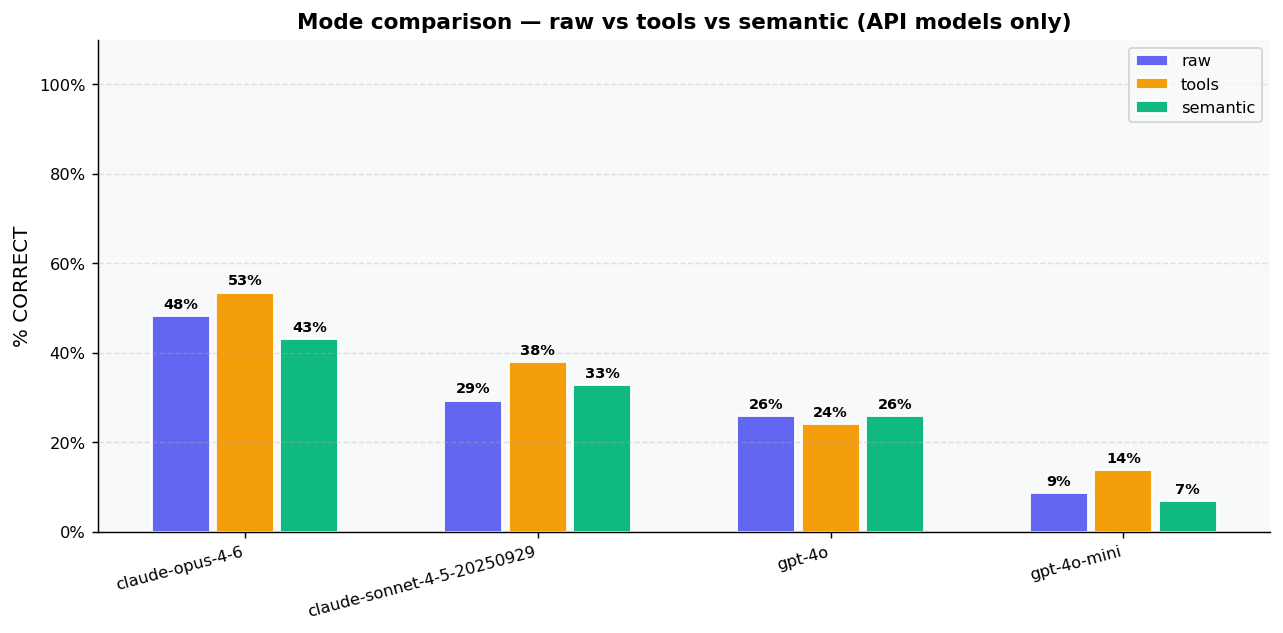

In [81]:
# Only API models that appear in all 3 modes
mode_counts = df.groupby("model")["mode"].nunique()
api_models = sorted(mode_counts[mode_counts == 3].index)
print(f"Models present in all 3 modes: {api_models}")

modes = ["raw", "tools", "semantic"]
MODE_COLORS = {"raw": "#6366f1", "tools": "#f59e0b", "semantic": "#10b981"}

fig, ax = plt.subplots(figsize=(10, 5))

n_models = len(api_models)
n_modes = len(modes)
bar_w = 0.22
x = np.arange(n_models)

for mi, mode in enumerate(modes):
    accs = []
    for m in api_models:
        sub = df[(df["model"] == m) & (df["mode"] == mode)]
        accs.append((sub["grade"] == "CORRECT").mean() if len(sub) else 0)
    offset = (mi - n_modes / 2 + 0.5) * bar_w
    bars = ax.bar(x + offset, accs, width=bar_w * 0.9, label=mode,
                  color=MODE_COLORS[mode], edgecolor="white")
    for bar, v in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                f"{v:.0%}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(api_models, rotation=15, ha="right")
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel("% CORRECT")
ax.set_title("Mode comparison — raw vs tools vs semantic (API models only)")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.35)
ax.grid(axis="x", alpha=0)

plt.tight_layout()
plt.show()

Models in all 3 modes (excl. errors): ['claude-opus-4-6', 'claude-sonnet-4-5-20250929', 'gpt-4o', 'gpt-4o-mini']


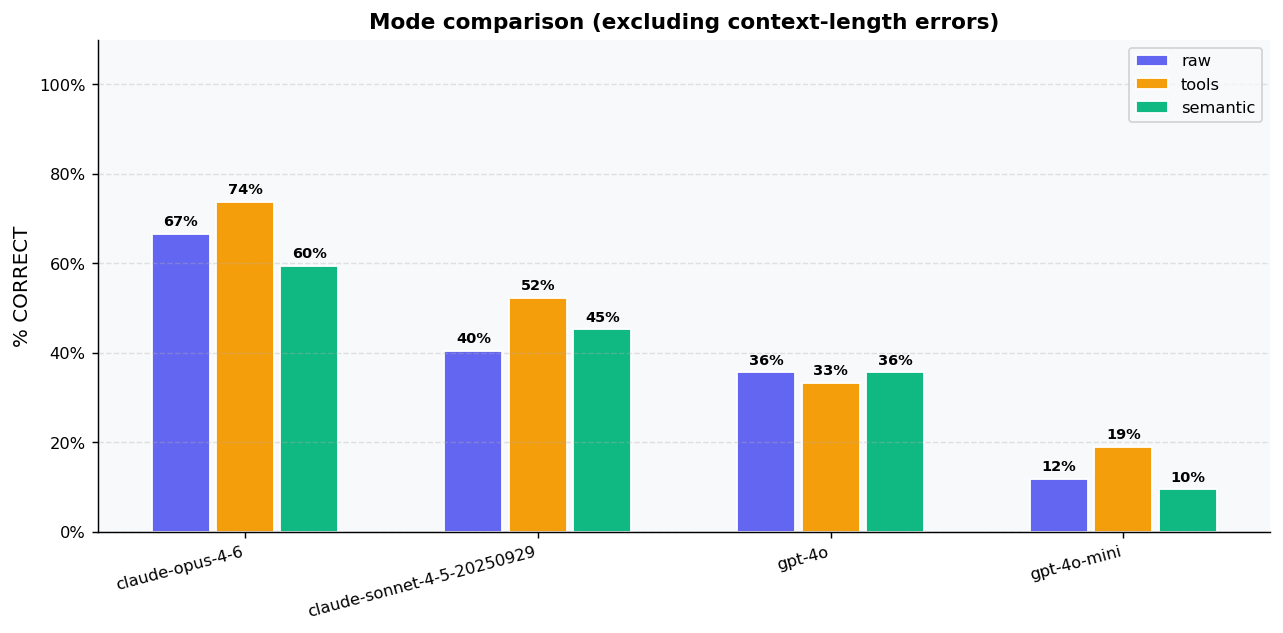

In [82]:
# Mode comparison excluding context-length errors
mode_counts_ok = df_ok.groupby("model")["mode"].nunique()
api_models_ok = sorted(mode_counts_ok[mode_counts_ok == 3].index)
print(f"Models in all 3 modes (excl. errors): {api_models_ok}")

modes = ["raw", "tools", "semantic"]
MODE_COLORS = {"raw": "#6366f1", "tools": "#f59e0b", "semantic": "#10b981"}

fig, ax = plt.subplots(figsize=(10, 5))

n_models = len(api_models_ok)
n_modes = len(modes)
bar_w = 0.22
x = np.arange(n_models)

for mi, mode in enumerate(modes):
    accs = []
    for m in api_models_ok:
        sub = df_ok[(df_ok["model"] == m) & (df_ok["mode"] == mode)]
        accs.append((sub["grade"] == "CORRECT").mean() if len(sub) else 0)
    offset = (mi - n_modes / 2 + 0.5) * bar_w
    bars = ax.bar(x + offset, accs, width=bar_w * 0.9, label=mode,
                  color=MODE_COLORS[mode], edgecolor="white")
    for bar, v in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                f"{v:.0%}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(api_models_ok, rotation=15, ha="right")
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel("% CORRECT")
ax.set_title("Mode comparison (excluding context-length errors)")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.35)
ax.grid(axis="x", alpha=0)

plt.tight_layout()
plt.show()

---
## 4 — Performance by template / question type (heatmap)

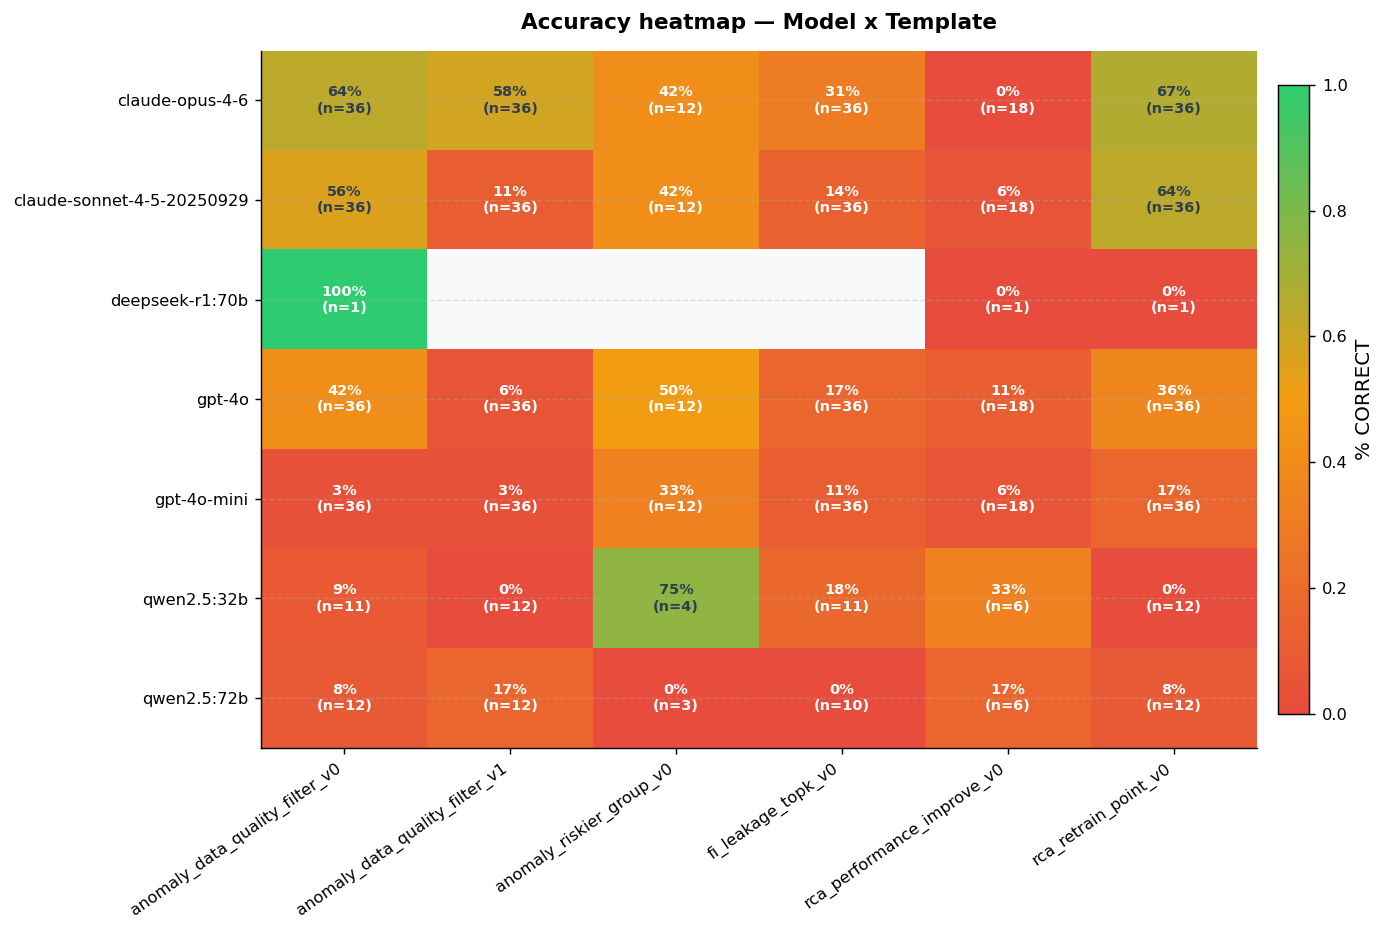

In [83]:
models = sorted(df["model"].unique())
templates = sorted(df["template_id"].unique())

matrix = np.full((len(models), len(templates)), np.nan)
counts = np.zeros_like(matrix, dtype=int)

for i, m in enumerate(models):
    for j, t in enumerate(templates):
        sub = df[(df["model"] == m) & (df["template_id"] == t)]
        if len(sub):
            matrix[i, j] = (sub["grade"] == "CORRECT").mean()
            counts[i, j] = len(sub)

cmap = LinearSegmentedColormap.from_list("rg", ["#e74c3c", "#f39c12", "#2ecc71"], N=256)

fig, ax = plt.subplots(
    figsize=(max(8, len(templates) * 1.8), max(3, len(models) * 0.9 + 1))
)
im = ax.imshow(matrix, aspect="auto", cmap=cmap, vmin=0, vmax=1)

ax.set_xticks(range(len(templates)))
ax.set_xticklabels(templates, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models, fontsize=9)

for i in range(len(models)):
    for j in range(len(templates)):
        v = matrix[i, j]
        n = counts[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}\n(n={n})", ha="center", va="center",
                    fontsize=8, fontweight="bold",
                    color="white" if v < 0.55 or v > 0.75 else "#2c3e50")

plt.colorbar(im, ax=ax, label="% CORRECT", fraction=0.03, pad=0.02)
ax.set_title("Accuracy heatmap — Model x Template", pad=12)
plt.tight_layout()
plt.show()

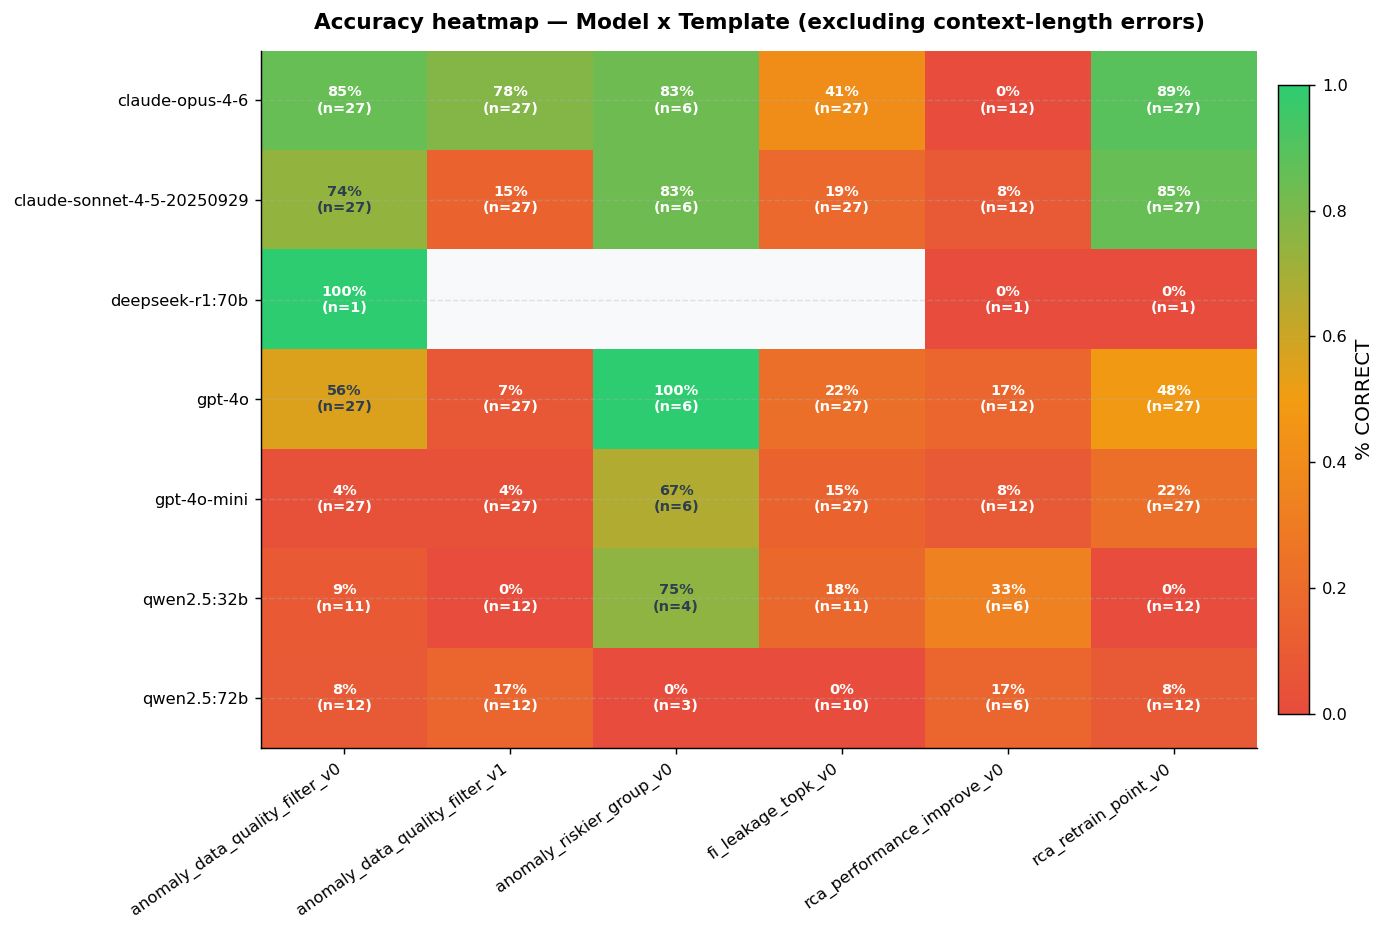

In [84]:
# Heatmap excluding context-length errors
models_ok = sorted(df_ok["model"].unique())
templates_ok = sorted(df_ok["template_id"].unique())

matrix_ok = np.full((len(models_ok), len(templates_ok)), np.nan)
counts_ok = np.zeros_like(matrix_ok, dtype=int)

for i, m in enumerate(models_ok):
    for j, t in enumerate(templates_ok):
        sub = df_ok[(df_ok["model"] == m) & (df_ok["template_id"] == t)]
        if len(sub):
            matrix_ok[i, j] = (sub["grade"] == "CORRECT").mean()
            counts_ok[i, j] = len(sub)

cmap = LinearSegmentedColormap.from_list("rg", ["#e74c3c", "#f39c12", "#2ecc71"], N=256)

fig, ax = plt.subplots(
    figsize=(max(8, len(templates_ok) * 1.8), max(3, len(models_ok) * 0.9 + 1))
)
im = ax.imshow(matrix_ok, aspect="auto", cmap=cmap, vmin=0, vmax=1)

ax.set_xticks(range(len(templates_ok)))
ax.set_xticklabels(templates_ok, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(models_ok)))
ax.set_yticklabels(models_ok, fontsize=9)

for i in range(len(models_ok)):
    for j in range(len(templates_ok)):
        v = matrix_ok[i, j]
        n = counts_ok[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}\n(n={n})", ha="center", va="center",
                    fontsize=8, fontweight="bold",
                    color="white" if v < 0.55 or v > 0.75 else "#2c3e50")

plt.colorbar(im, ax=ax, label="% CORRECT", fraction=0.03, pad=0.02)
ax.set_title("Accuracy heatmap — Model x Template (excluding context-length errors)", pad=12)
plt.tight_layout()
plt.show()

---
## 5 — Performance by dataset size

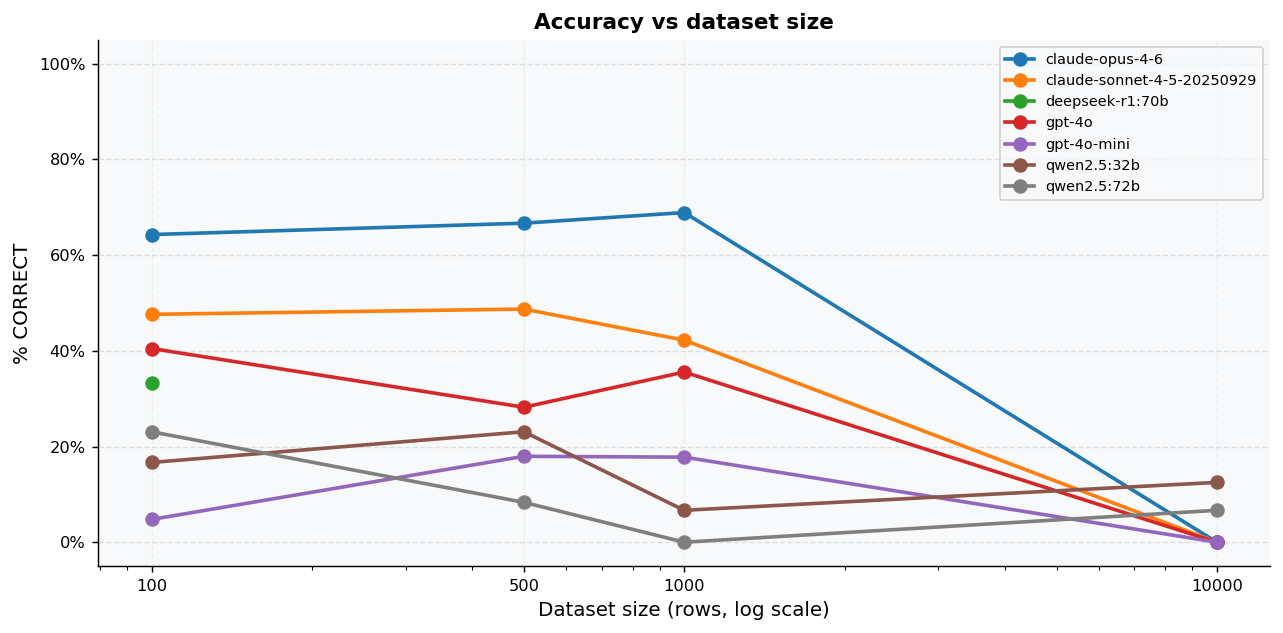

In [85]:
sizes = sorted(df["dataset_size"].dropna().unique().astype(int))
models = sorted(df["model"].unique())
MODEL_COLORS = plt.cm.tab10(np.linspace(0, 0.7, len(models)))

if len(sizes) < 2:
    print("Only one dataset size — skipping size trend plot.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    for mi, m in enumerate(models):
        accs = []
        for s in sizes:
            sub = df[(df["model"] == m) & (df["dataset_size"] == s)]
            accs.append((sub["grade"] == "CORRECT").mean() if len(sub) else np.nan)
        ax.plot(sizes, accs, "o-", color=MODEL_COLORS[mi], label=m,
                linewidth=2, markersize=7)

    ax.set_xscale("log")
    ax.set_xticks(sizes)
    ax.set_xticklabels([str(s) for s in sizes])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_xlabel("Dataset size (rows, log scale)")
    ax.set_ylabel("% CORRECT")
    ax.set_title("Accuracy vs dataset size")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8, loc="best")
    ax.grid(axis="y", alpha=0.35)
    ax.grid(axis="x", alpha=0.15)

    plt.tight_layout()
    plt.show()

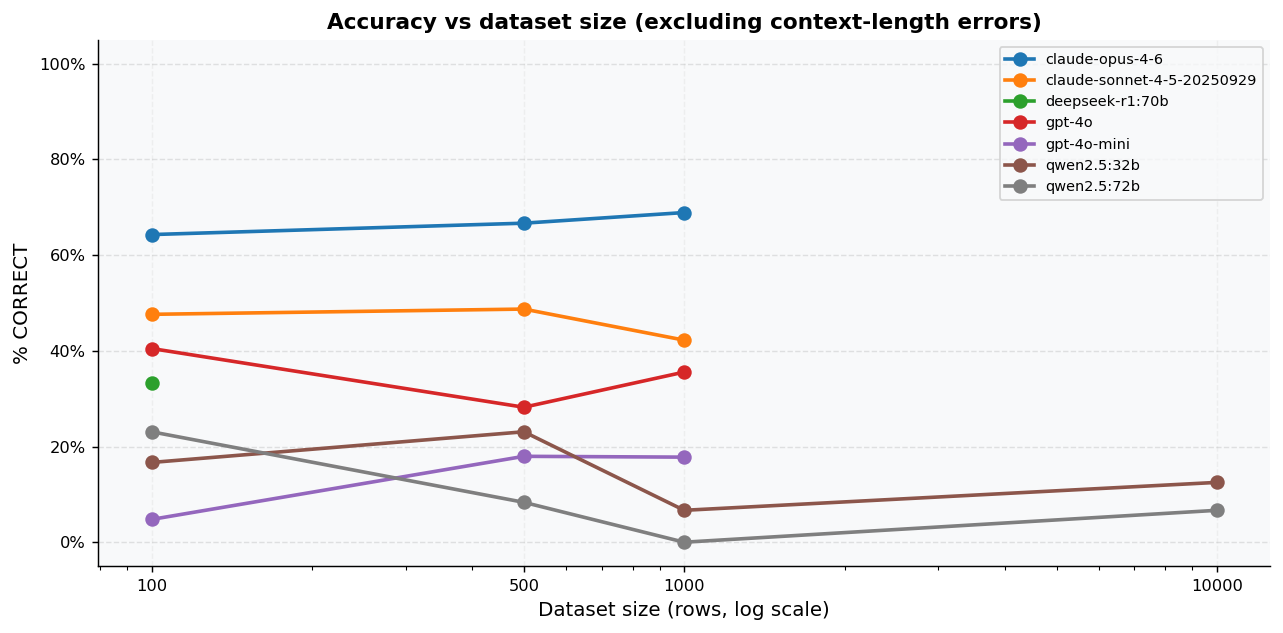

In [86]:
# Dataset size chart excluding context-length errors
sizes_ok = sorted(df_ok["dataset_size"].dropna().unique().astype(int))
models_ok = sorted(df_ok["model"].unique())
MODEL_COLORS_OK = plt.cm.tab10(np.linspace(0, 0.7, len(models_ok)))

if len(sizes_ok) < 2:
    print("Only one dataset size after excluding errors — skipping.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    for mi, m in enumerate(models_ok):
        accs = []
        for s in sizes_ok:
            sub = df_ok[(df_ok["model"] == m) & (df_ok["dataset_size"] == s)]
            accs.append((sub["grade"] == "CORRECT").mean() if len(sub) else np.nan)
        ax.plot(sizes_ok, accs, "o-", color=MODEL_COLORS_OK[mi], label=m,
                linewidth=2, markersize=7)

    ax.set_xscale("log")
    ax.set_xticks(sizes_ok)
    ax.set_xticklabels([str(s) for s in sizes_ok])
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_xlabel("Dataset size (rows, log scale)")
    ax.set_ylabel("% CORRECT")
    ax.set_title("Accuracy vs dataset size (excluding context-length errors)")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8, loc="best")
    ax.grid(axis="y", alpha=0.35)
    ax.grid(axis="x", alpha=0.15)

    plt.tight_layout()
    plt.show()

---
## 6 — Performance by injector category

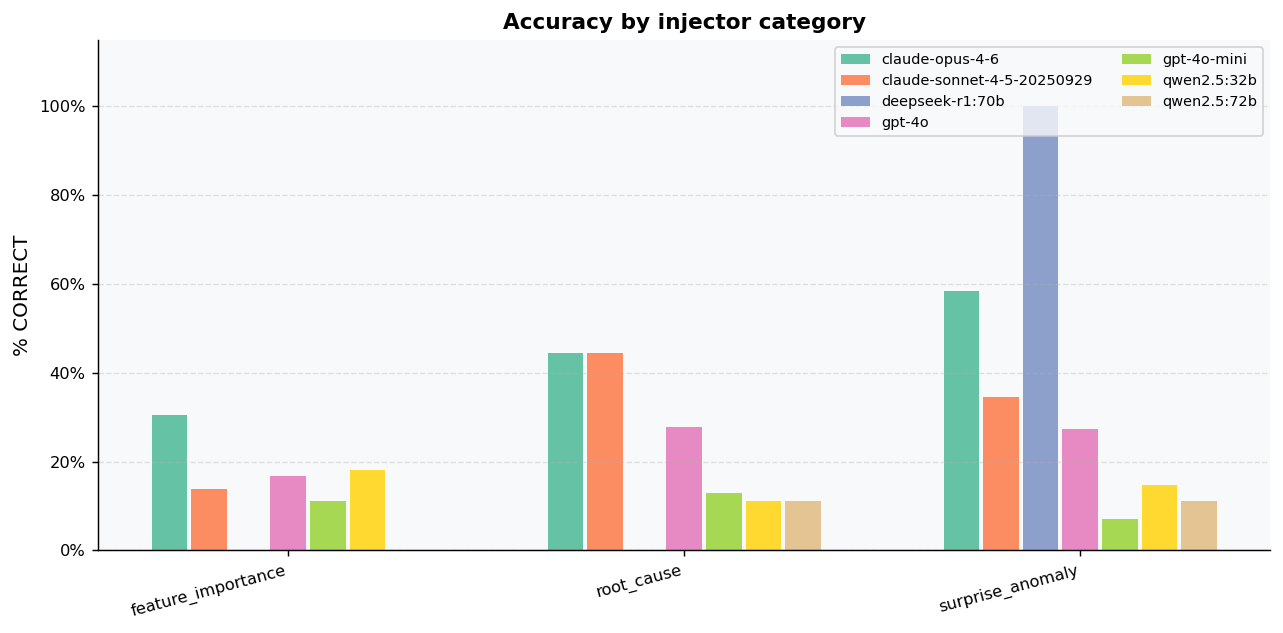

In [87]:
categories = sorted(df["category"].unique())
models = sorted(df["model"].unique())

CAT_PALETTE = plt.cm.Set2(np.linspace(0, 0.8, len(models)))

fig, ax = plt.subplots(figsize=(10, 5))

n_cats = len(categories)
n_mdls = len(models)
bar_w = 0.7 / max(n_mdls, 1)
x = np.arange(n_cats)

for mi, m in enumerate(models):
    accs = []
    for c in categories:
        sub = df[(df["model"] == m) & (df["category"] == c)]
        accs.append((sub["grade"] == "CORRECT").mean() if len(sub) else 0)
    offset = (mi - n_mdls / 2 + 0.5) * bar_w
    ax.bar(x + offset, accs, width=bar_w * 0.9, color=CAT_PALETTE[mi], label=m)

ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=15, ha="right")
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel("% CORRECT")
ax.set_title("Accuracy by injector category")
ax.legend(fontsize=8, loc="upper right", ncol=2)
ax.grid(axis="y", alpha=0.35)
ax.grid(axis="x", alpha=0)

plt.tight_layout()
plt.show()

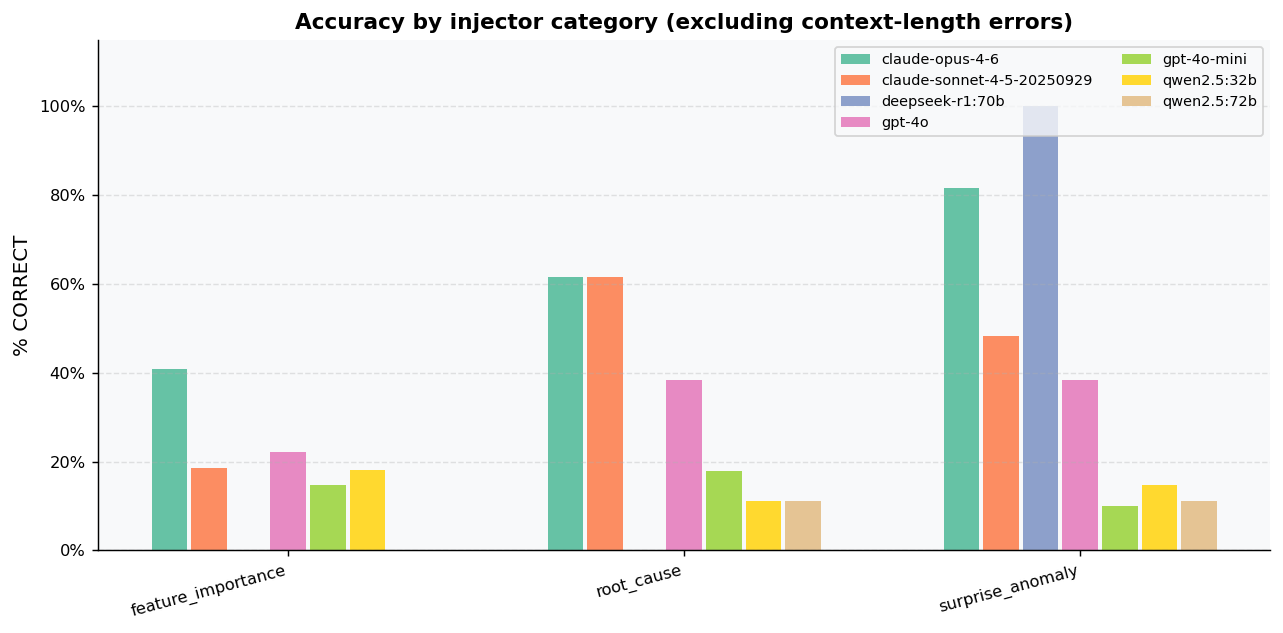

In [88]:
# Injector category chart excluding context-length errors
categories_ok = sorted(df_ok["category"].unique())
models_ok = sorted(df_ok["model"].unique())

CAT_PALETTE_OK = plt.cm.Set2(np.linspace(0, 0.8, len(models_ok)))

fig, ax = plt.subplots(figsize=(10, 5))

n_cats = len(categories_ok)
n_mdls = len(models_ok)
bar_w = 0.7 / max(n_mdls, 1)
x = np.arange(n_cats)

for mi, m in enumerate(models_ok):
    accs = []
    for c in categories_ok:
        sub = df_ok[(df_ok["model"] == m) & (df_ok["category"] == c)]
        accs.append((sub["grade"] == "CORRECT").mean() if len(sub) else 0)
    offset = (mi - n_mdls / 2 + 0.5) * bar_w
    ax.bar(x + offset, accs, width=bar_w * 0.9, color=CAT_PALETTE_OK[mi], label=m)

ax.set_xticks(x)
ax.set_xticklabels(categories_ok, rotation=15, ha="right")
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel("% CORRECT")
ax.set_title("Accuracy by injector category (excluding context-length errors)")
ax.legend(fontsize=8, loc="upper right", ncol=2)
ax.grid(axis="y", alpha=0.35)
ax.grid(axis="x", alpha=0)

plt.tight_layout()
plt.show()

---
## 7 — Context-length error analysis

Context-length errors: 192 / 810 (23.7%)
Affected datasets: ['bike_sharing_10000', 'california_housing_10000', 'vgsales_10000']



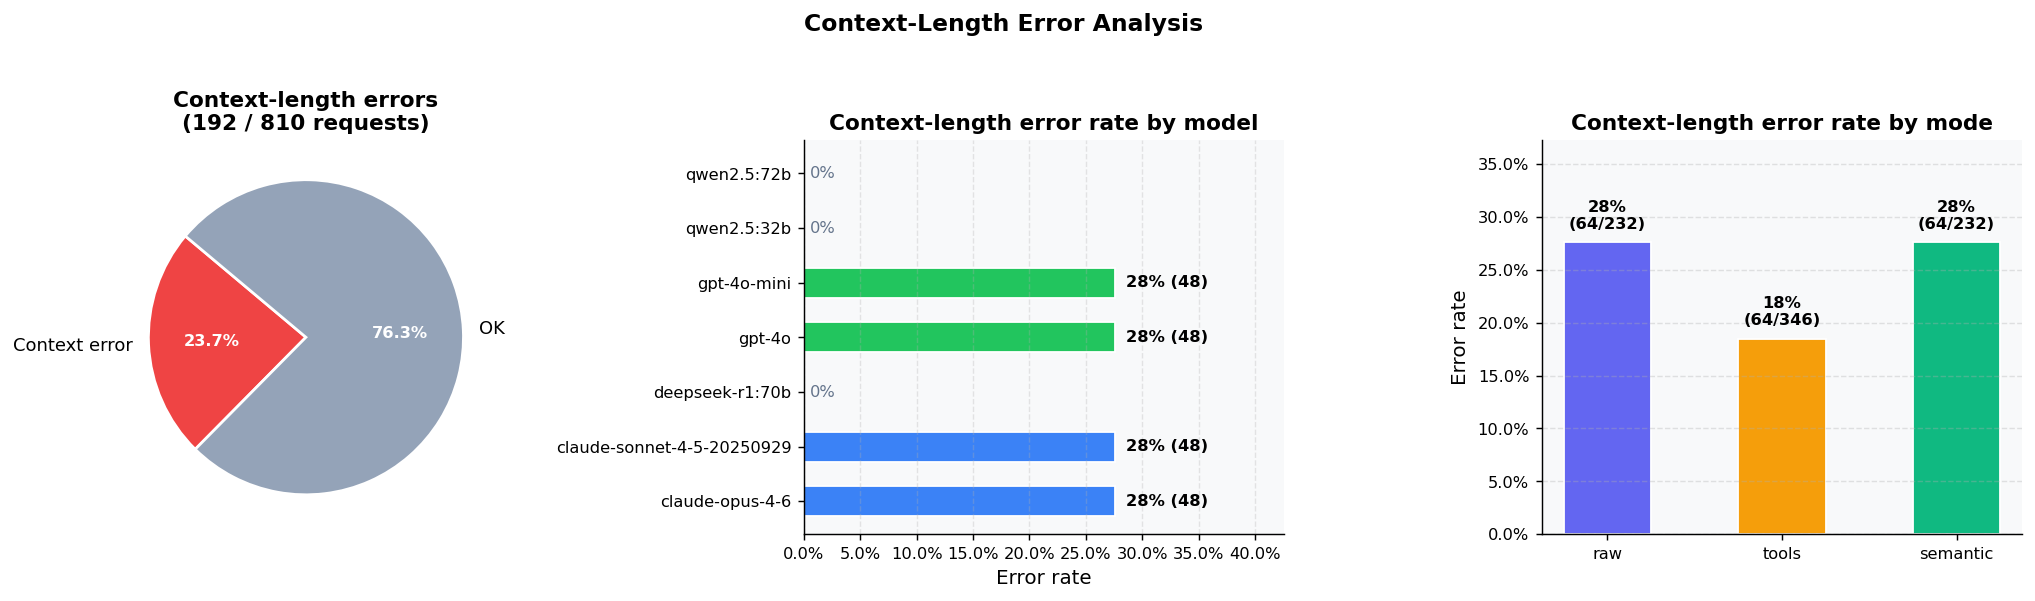


Context-length errors by model x mode:
                                     errors  total rate
model                      mode                        
claude-opus-4-6            raw           16     58  28%
                           semantic      16     58  28%
                           tools         16     58  28%
claude-sonnet-4-5-20250929 raw           16     58  28%
                           semantic      16     58  28%
                           tools         16     58  28%
deepseek-r1:70b            tools          0      3   0%
gpt-4o                     raw           16     58  28%
                           semantic      16     58  28%
                           tools         16     58  28%
gpt-4o-mini                raw           16     58  28%
                           semantic      16     58  28%
                           tools         16     58  28%
qwen2.5:32b                tools          0     56   0%
qwen2.5:72b                tools          0     55   0%


In [89]:
err_df = df[df["is_context_error"]]
total_errors = len(err_df)
print(f"Context-length errors: {total_errors} / {len(df)} ({total_errors/len(df):.1%})")
print(f"Affected datasets: {sorted(err_df['dataset'].unique())}")
print()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ── 7a: Overall error rate (pie) ─────────────────────────────────────────
ax = axes[0]
n_ok = len(df) - total_errors
wedges, texts, autotexts = ax.pie(
    [total_errors, n_ok],
    labels=["Context error", "OK"],
    colors=["#ef4444", "#94a3b8"],
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops=dict(linewidth=1.5, edgecolor="white"),
    textprops={"fontsize": 10},
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_color("white")
    at.set_fontweight("bold")
ax.set_title(f"Context-length errors\n({total_errors} / {len(df)} requests)")

# ── 7b: Error rate by model ──────────────────────────────────────────────
ax2 = axes[1]
models = sorted(df["model"].unique())
err_rates = []
err_counts = []
for m in models:
    sub = df[df["model"] == m]
    n_err = sub["is_context_error"].sum()
    err_rates.append(n_err / len(sub))
    err_counts.append(n_err)

colors = [PROVIDER_COLORS[infer_provider(m)] for m in models]
bars = ax2.barh(models, err_rates, color=colors, height=0.55, edgecolor="white")
for bar, rate, count in zip(bars, err_rates, err_counts):
    if rate > 0:
        ax2.text(rate + 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{rate:.0%} ({count})", va="center", fontsize=9, fontweight="bold")
    else:
        ax2.text(0.005, bar.get_y() + bar.get_height() / 2,
                 "0%", va="center", fontsize=9, color="#64748b")

ax2.set_xlim(0, max(err_rates) + 0.15 if max(err_rates) > 0 else 0.1)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.set_xlabel("Error rate")
ax2.set_title("Context-length error rate by model")
ax2.grid(axis="x", alpha=0.3)
ax2.grid(axis="y", alpha=0)

# ── 7c: Error rate by mode ───────────────────────────────────────────────
ax3 = axes[2]
MODE_COLORS = {"raw": "#6366f1", "tools": "#f59e0b", "semantic": "#10b981"}
modes = ["raw", "tools", "semantic"]
mode_err_rates = []
mode_err_counts = []
mode_totals = []
for mode in modes:
    sub = df[df["mode"] == mode]
    n_err = sub["is_context_error"].sum()
    mode_err_rates.append(n_err / len(sub) if len(sub) else 0)
    mode_err_counts.append(n_err)
    mode_totals.append(len(sub))

bars = ax3.bar(modes, mode_err_rates,
               color=[MODE_COLORS[m] for m in modes],
               width=0.5, edgecolor="white")
for bar, rate, count, total in zip(bars, mode_err_rates, mode_err_counts, mode_totals):
    ax3.text(bar.get_x() + bar.get_width() / 2, rate + 0.01,
             f"{rate:.0%}\n({count}/{total})",
             ha="center", va="bottom", fontsize=9, fontweight="bold")

ax3.set_ylim(0, max(mode_err_rates) * 1.35 if max(mode_err_rates) > 0 else 0.1)
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax3.set_ylabel("Error rate")
ax3.set_title("Context-length error rate by mode")
ax3.grid(axis="y", alpha=0.35)
ax3.grid(axis="x", alpha=0)

plt.suptitle("Context-Length Error Analysis", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── Breakdown table ──────────────────────────────────────────────────────
print("\nContext-length errors by model x mode:")
pivot = (
    df.groupby(["model", "mode"])["is_context_error"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "errors", "count": "total"})
)
pivot["rate"] = (pivot["errors"] / pivot["total"]).map("{:.0%}".format)
print(pivot.to_string())

Context-length errors by dataset:

                          errors  total      rate rate_fmt
dataset                                                   
bike_sharing_100               0     71  0.000000       0%
california_housing_100         0     56  0.000000       0%
vgsales_100                    0     69  0.000000       0%
bike_sharing_500               0     56  0.000000       0%
california_housing_500         0     55  0.000000       0%
vgsales_500                    0     70  0.000000       0%
bike_sharing_1000              0     70  0.000000       0%
california_housing_1000        0     56  0.000000       0%
vgsales_1000                   0     84  0.000000       0%
vgsales_10000                 72     83  0.867470      87%
bike_sharing_10000            72     84  0.857143      86%
california_housing_10000      48     56  0.857143      86%

Datasets with errors: 3 / 12


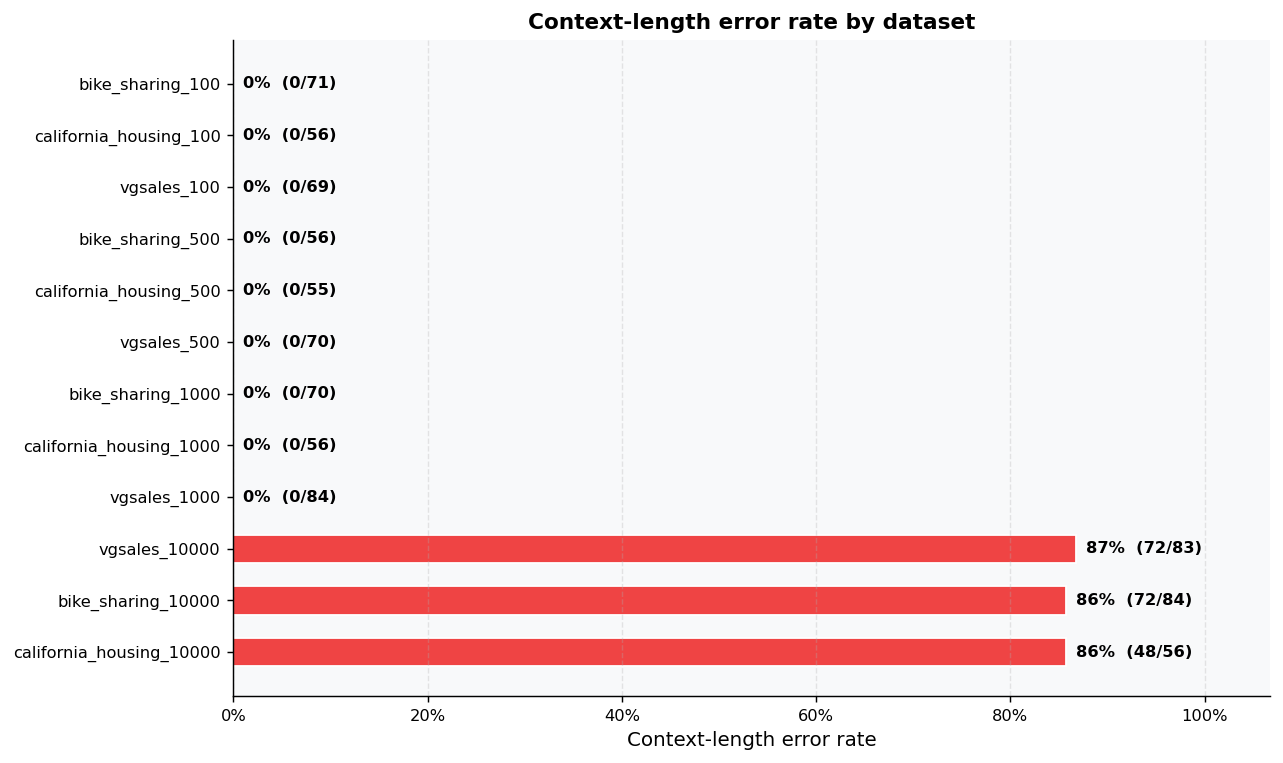

In [90]:
# Context-length errors grouped by dataset
ctx_by_ds = (
    df.groupby("dataset")["is_context_error"]
    .agg(errors="sum", total="count")
    .assign(rate=lambda x: x["errors"] / x["total"])
)
ctx_by_ds["rate_fmt"] = ctx_by_ds["rate"].map("{:.0%}".format)

# Sort by dataset size, then alphabetically within each size group
ctx_by_ds["_size"] = ctx_by_ds.index.map(_parse_size)
ctx_by_ds = ctx_by_ds.sort_values(["_size", "rate"], ascending=[True, False]).drop(columns="_size")

print("Context-length errors by dataset:\n")
print(ctx_by_ds.to_string())
print(f"\nDatasets with errors: {(ctx_by_ds['errors'] > 0).sum()} / {len(ctx_by_ds)}")

# Bar chart — invert order so smallest sizes are at top
plot_order = ctx_by_ds.iloc[::-1]
fig, ax = plt.subplots(figsize=(10, max(3, len(plot_order) * 0.5)))
colors = ["#ef4444" if r > 0 else "#94a3b8" for r in plot_order["rate"]]
bars = ax.barh(plot_order.index, plot_order["rate"], color=colors, height=0.55, edgecolor="white")
for bar, (_, row) in zip(bars, plot_order.iterrows()):
    label = f"{row['rate_fmt']}  ({int(row['errors'])}/{int(row['total'])})"
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            label, va="center", fontsize=9, fontweight="bold")

ax.set_xlim(0, ctx_by_ds["rate"].max() + 0.2 if ctx_by_ds["rate"].max() > 0 else 0.1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel("Context-length error rate")
ax.set_title("Context-length error rate by dataset")
ax.grid(axis="x", alpha=0.3)
ax.grid(axis="y", alpha=0)
plt.tight_layout()
plt.show()

---
## 8 — Template type x Mode accuracy

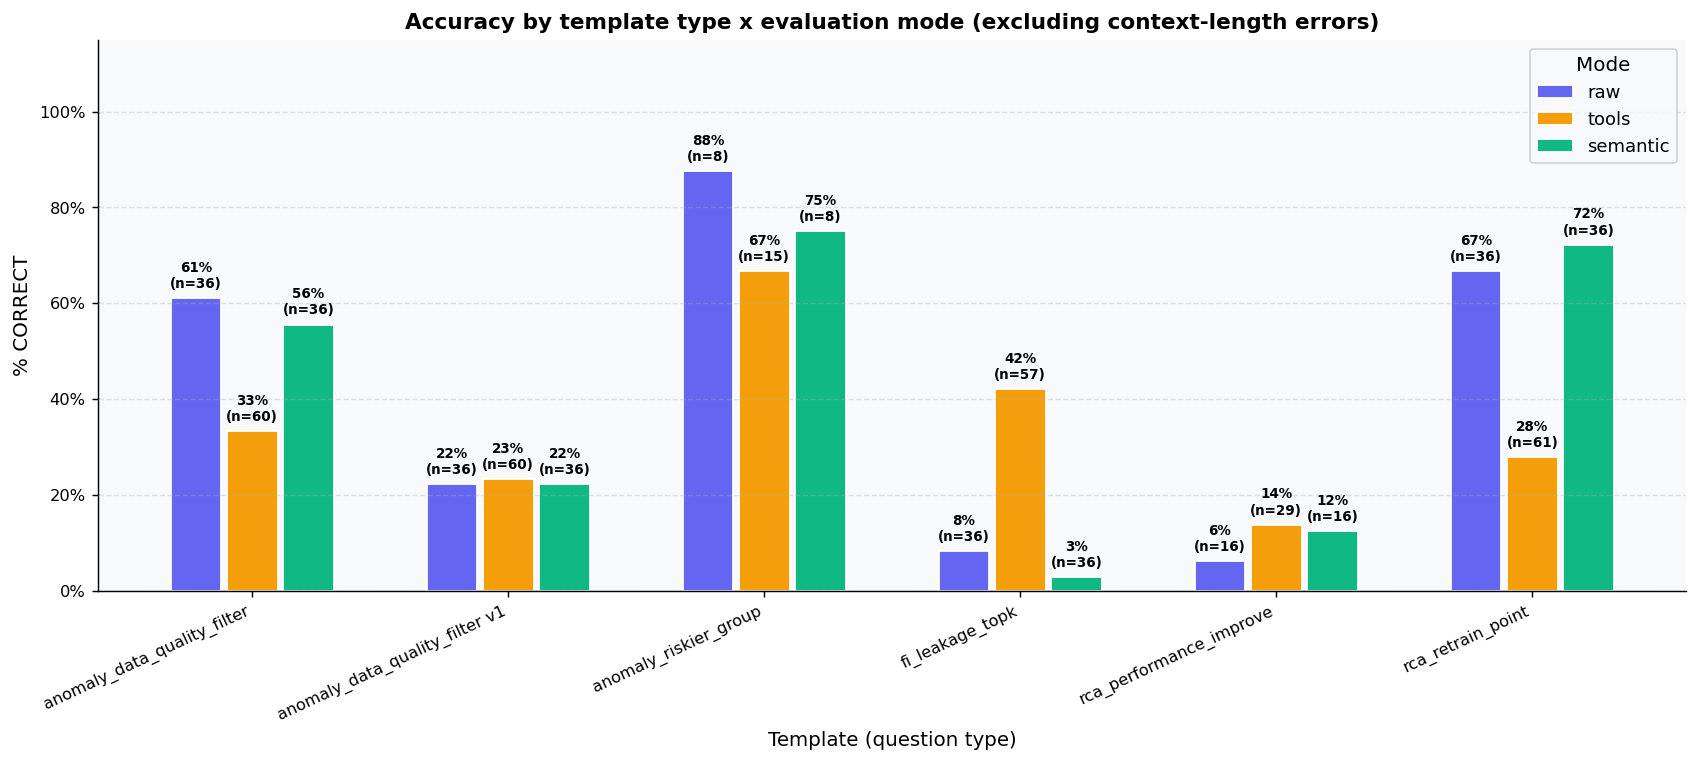

In [91]:
# Accuracy by template_id x mode (raw / tools / semantic)
# Exclude context-length errors for a cleaner signal
modes = ["raw", "tools", "semantic"]
MODE_COLORS = {"raw": "#6366f1", "tools": "#f59e0b", "semantic": "#10b981"}

templates = sorted(df_ok["template_id"].unique())
# Shorten template labels for readability
short_labels = [t.replace("_v0", "").replace("_v1", " v1") for t in templates]

fig, ax = plt.subplots(figsize=(max(10, len(templates) * 2.2), 6))

n_templates = len(templates)
n_modes = len(modes)
bar_w = 0.22
x = np.arange(n_templates)

for mi, mode in enumerate(modes):
    accs = []
    ns = []
    for t in templates:
        sub = df_ok[(df_ok["template_id"] == t) & (df_ok["mode"] == mode)]
        if len(sub):
            accs.append((sub["grade"] == "CORRECT").mean())
            ns.append(len(sub))
        else:
            accs.append(0)
            ns.append(0)
    offset = (mi - n_modes / 2 + 0.5) * bar_w
    bars = ax.bar(x + offset, accs, width=bar_w * 0.9, label=mode,
                  color=MODE_COLORS[mode], edgecolor="white")
    for bar, v, n in zip(bars, accs, ns):
        if n > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.015,
                    f"{v:.0%}\n(n={n})", ha="center", va="bottom",
                    fontsize=7.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=25, ha="right", fontsize=9)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylabel("% CORRECT")
ax.set_xlabel("Template (question type)")
ax.set_title("Accuracy by template type x evaluation mode (excluding context-length errors)")
ax.legend(fontsize=10, title="Mode")
ax.grid(axis="y", alpha=0.35)
ax.grid(axis="x", alpha=0)

plt.tight_layout()
plt.show()